# Roman strong-lens population

Simulate a seeded ensemble of Roman strong lenses, inspect representative detector images, and measure how the posterior detection threshold changes catalog recovery and contamination.

Reading from /Users/tdaylan/Documents/work/git/pcat/examples/roman_strong_lens_perturber_catalog/roman_strong_lens_perturber_catalog.py...


{'number_lenses': 20, 'number_injected': 10, 'true_positive_rate': 0.2, 'true_positive_rate_lower': 0.10362299537513232, 'true_positive_rate_upper': 0.3509224591703222, 'false_positive_rate': 0.0, 'false_positive_rate_lower': 0.0, 'false_positive_rate_upper': 0.09090909090909091, 'localization_rate': 0.9, 'mean_posterior_injected': 0.19990256338699325, 'mean_posterior_null': 9.200207306771193e-06}
Reading from /Users/tdaylan/Documents/work/git/pcat/examples/roman_strong_lens_perturber_catalog/visuals/roman_strong_lens_perturber_catalog.png...


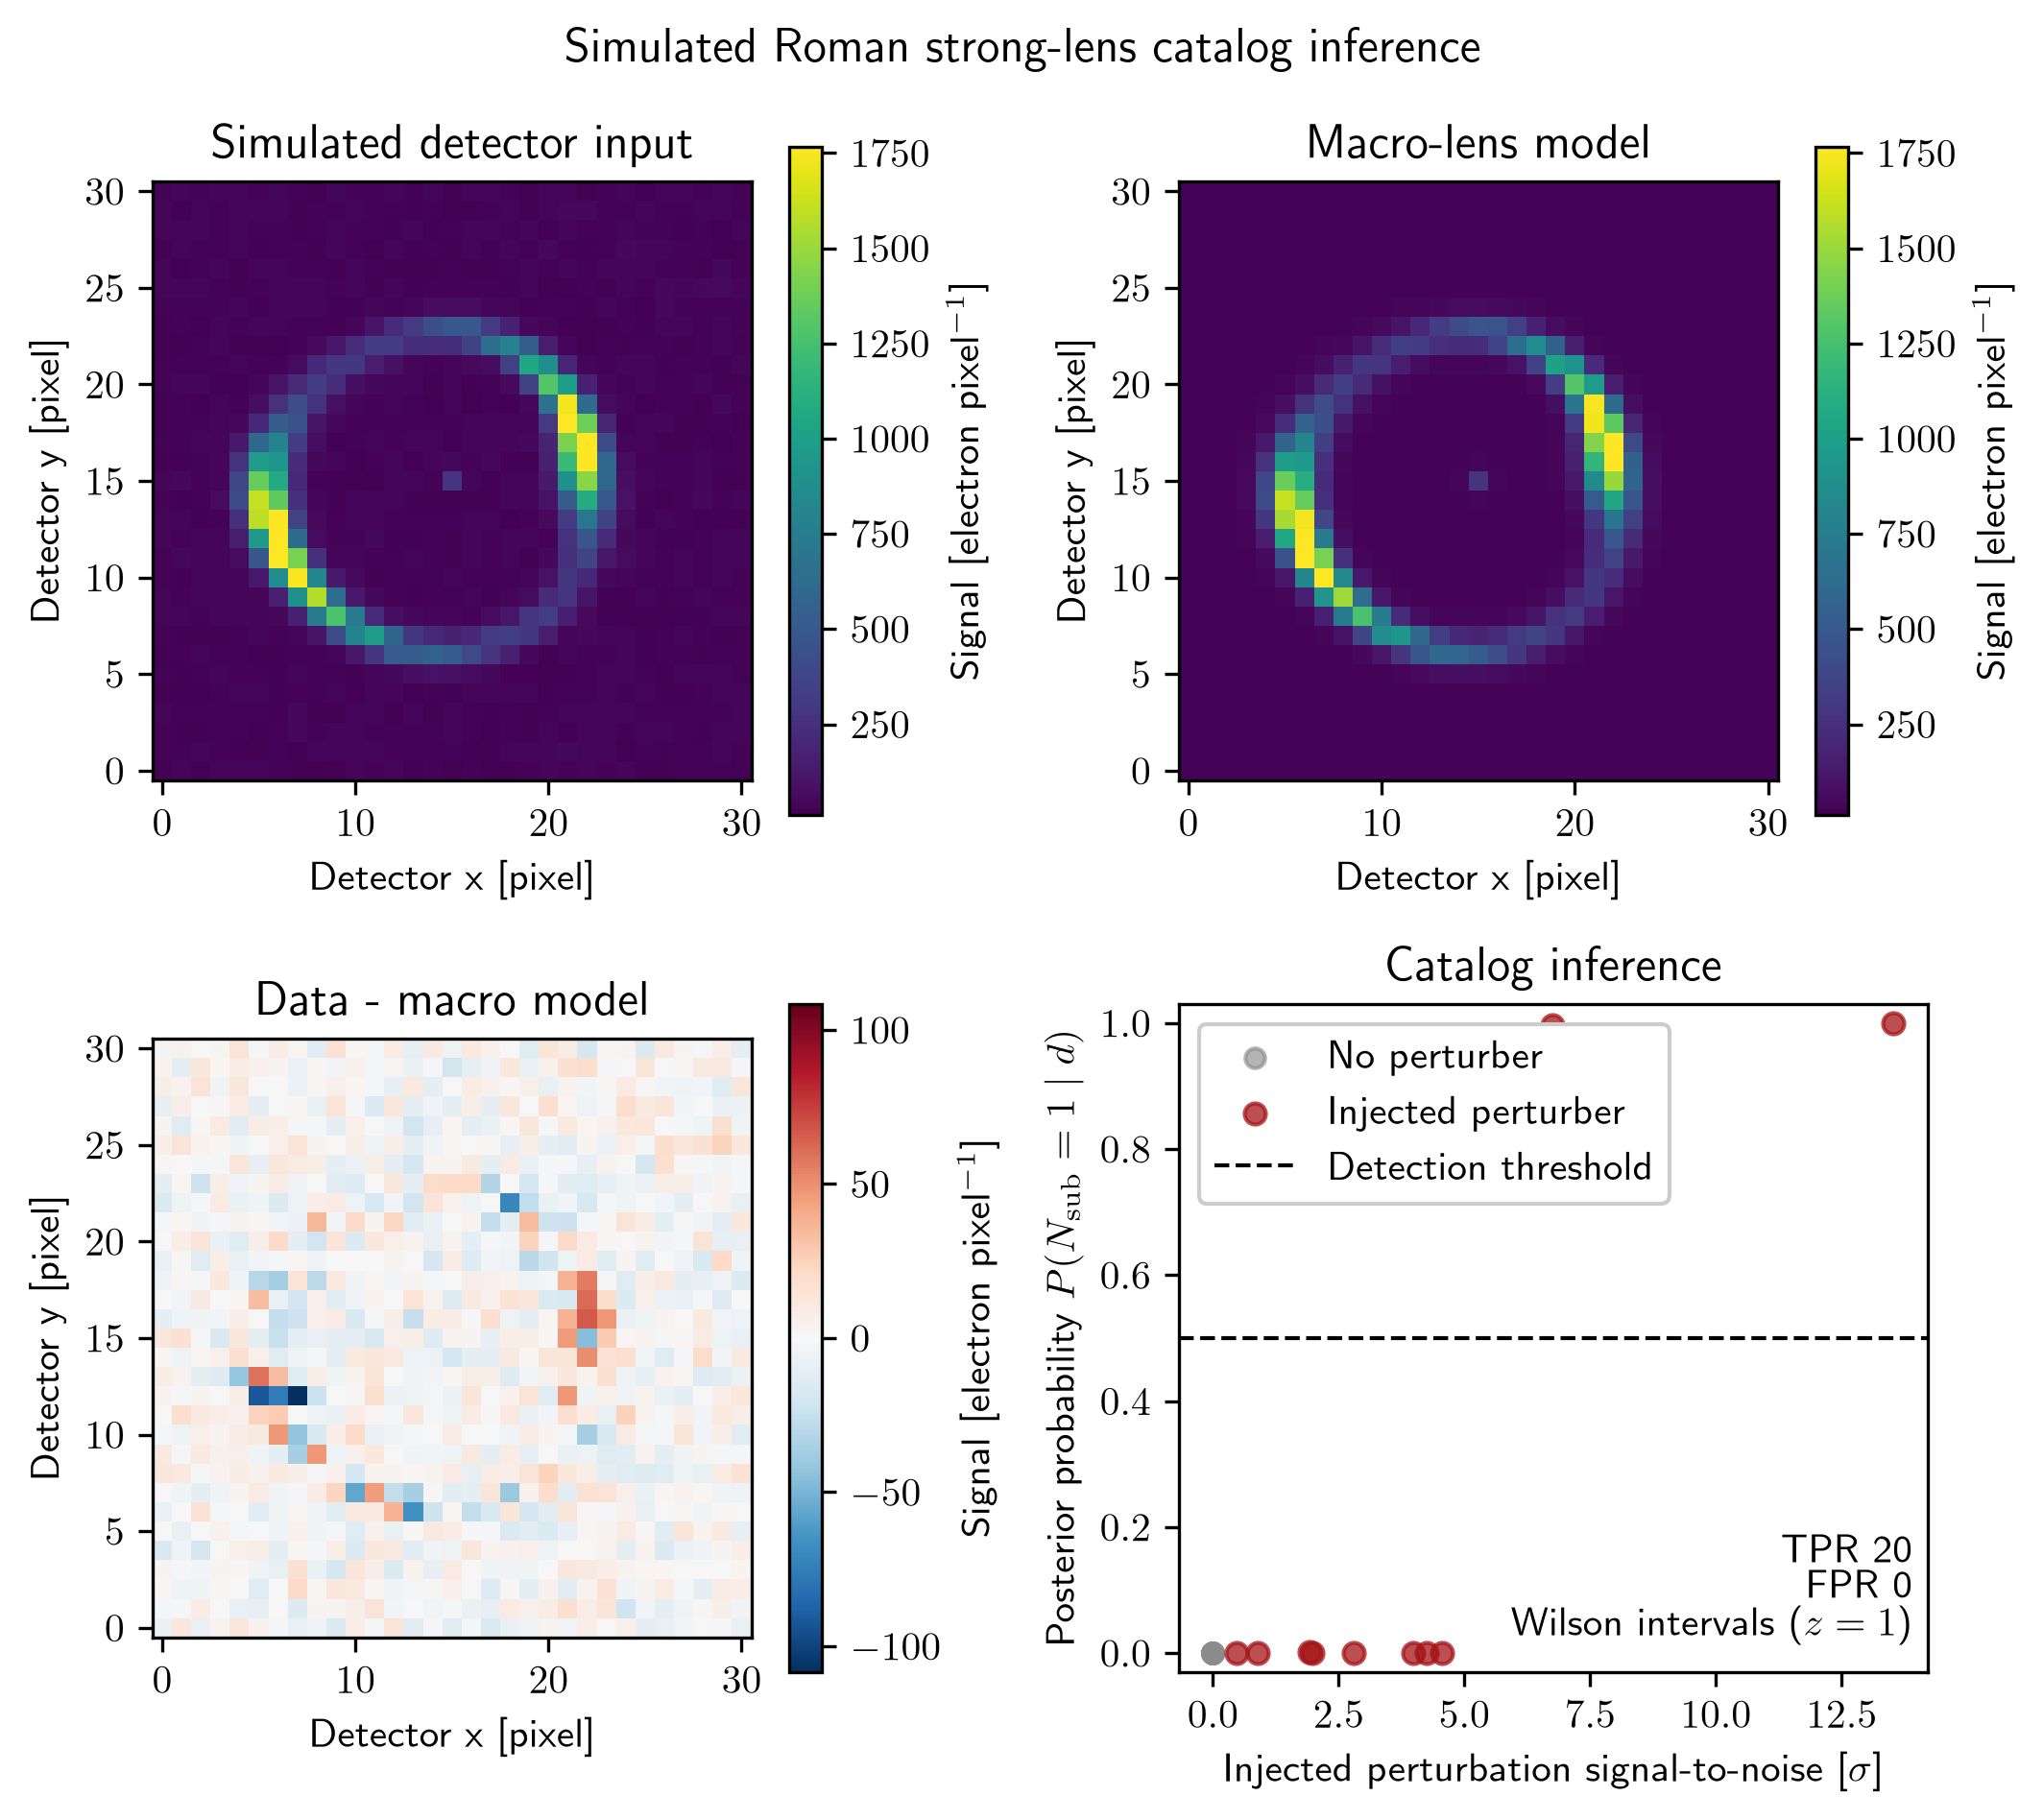

In [1]:
from pathlib import Path
import importlib.util
from IPython.display import Image, display

candidates = (
    root / 'examples/roman_strong_lens_perturber_catalog/roman_strong_lens_perturber_catalog.py'
    for root in (Path.cwd(), *Path.cwd().parents)
)
script = next(path for path in candidates if path.is_file())
print(f'Reading from {script}...')
specification = importlib.util.spec_from_file_location('roman_lens_example', script)
module = importlib.util.module_from_spec(specification)
specification.loader.exec_module(module)
output_path = script.parent / 'visuals/roman_strong_lens_perturber_catalog.png'
summary = module.run_example(output_path, number_lenses=20)
print(summary)
print(f'Reading from {output_path}...')
display(Image(filename=str(output_path)))

## Detection threshold

A separate seeded 100-lens population measures how the posterior threshold balances recovery of injected perturbers against detections in null lenses.

Writing to /Users/tdaylan/Documents/work/git/pcat/examples/roman_strong_lens_perturber_catalog/visuals/roman_lens_threshold_tradeoff.png...
Reading from /Users/tdaylan/Documents/work/git/pcat/examples/roman_strong_lens_perturber_catalog/visuals/roman_lens_threshold_tradeoff.png...


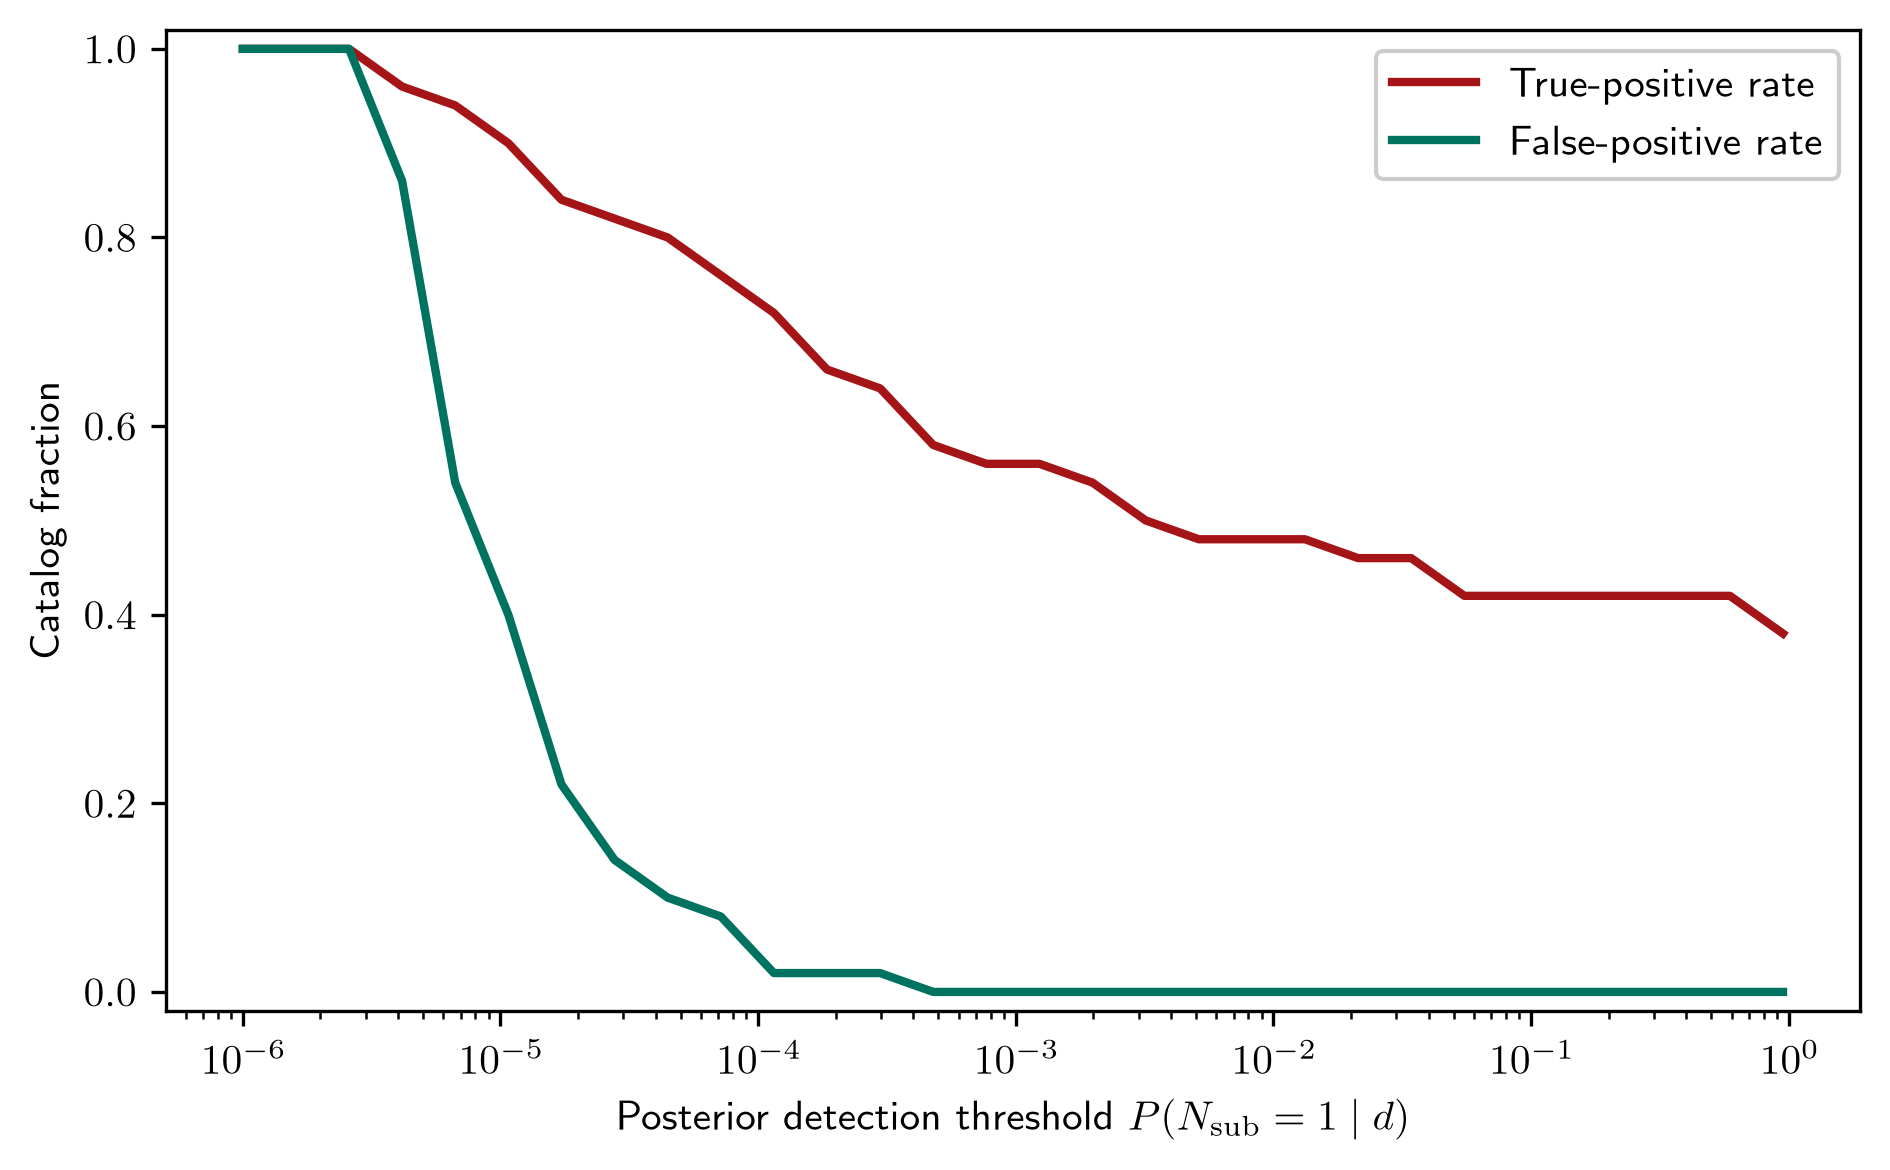

In [2]:
import matplotlib.pyplot as plt
import numpy as np

records, _ = module.simulate_population(number_lenses=100, seed=814)
thresholds = np.geomspace(1.0e-6, 0.95, 30)
threshold_summaries = [
    module.summarize_population(records, detection_threshold=threshold)
    for threshold in thresholds
]
true_positive_rate = np.array([
    result['true_positive_rate'] for result in threshold_summaries
])
false_positive_rate = np.array([
    result['false_positive_rate'] for result in threshold_summaries
])

figure, axis = plt.subplots(figsize=(6.4, 4.0), facecolor='white')
axis.plot(thresholds, true_positive_rate, color='#A51417', linewidth=2.0, label='True-positive rate')
axis.plot(thresholds, false_positive_rate, color='#007360', linewidth=2.0, label='False-positive rate')
axis.set_xlabel(r'Posterior detection threshold $P(N_{\rm sub}=1\mid d)$')
axis.set_ylabel('Catalog fraction')
axis.set_xscale('log')
axis.set_ylim(-0.02, 1.02)
axis.grid(False)
axis.legend(frameon=True, fancybox=True, framealpha=1.0)
figure.tight_layout()

threshold_path = script.parent / 'visuals/roman_lens_threshold_tradeoff.png'
print(f'Writing to {threshold_path}...')
figure.savefig(threshold_path, dpi=300, bbox_inches='tight')
plt.close(figure)
print(f'Reading from {threshold_path}...')
display(Image(filename=str(threshold_path)))